https://github.com/albermax/innvestigate

In [2]:
%tensorflow_version 1.x
!git clone https://github.com/albermax/innvestigate.git
!pip install /content/innvestigate --no-deps

TensorFlow 1.x selected.
fatal: destination path 'innvestigate' already exists and is not an empty directory.
Processing ./innvestigate
  Created wheel for innvestigate: filename=innvestigate-1.0.9-cp37-none-any.whl size=99900 sha256=111ce6a3c8551fc4279bf31be85ef2c972475ab3c1cf0ac5a31c689421156c71
  Stored in directory: /tmp/pip-ephem-wheel-cache-w_7029ga/wheels/11/b2/18/bf09e94dbb7a14d93a30170c94eadb9f2fe292e5c24d220428
Successfully built innvestigate
  Found existing installation: innvestigate 1.0.9
    Uninstalling innvestigate-1.0.9:
      Successfully uninstalled innvestigate-1.0.9


In [3]:
!pip install Biopython

In [4]:
%matplotlib inline  

import tarfile
import pandas as pd
import numpy as np
import re
from datetime import datetime

import keras
import keras.backend
import keras.layers
import keras.models
import keras.utils
import keras.metrics

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score
from keras.wrappers.scikit_learn import KerasClassifier

from keras.utils import to_categorical

from matplotlib import pyplot as plt

from Bio.Seq import Seq

import innvestigate
import innvestigate.utils as iutils

Using TensorFlow backend.


### Read data

In [5]:
filename = "training_data_v2.tar.gz"

data = tarfile.open(filename, "r:gz")
data.extractall()
data.close()

In [6]:
b = open('GRHL1_TCCAAC20NTA_Q_3.fasta','r')
bind = b.readlines()
b.close()

u = open('GRHL1_TCCAAC20NTA_Q_3_shuffled.fasta','r')
unbind = u.readlines()
u.close()

### Data preprocessing

In [7]:
bind = [v for v in bind if '>' not in v]
bind = [s.replace('\n', '') for s in bind]
bind = [x.upper() for x in bind]

unbind = [v for v in unbind if '>' not in v]
unbind = [s.replace('\n', '') for s in unbind]
unbind = [x.upper() for x in unbind]

In [8]:
print(len(bind), len(unbind))

203209 203209


Reverse Complement

In [9]:
bind_rev = list(range(len(bind)))

for i in range(len(bind)):
  seq = Seq(bind[i])
  rev = seq.reverse_complement()
  bind_rev[i] = str(rev)

unbind_rev = list(range(len(unbind)))

for i in range(len(unbind)):
  seq = Seq(unbind[i])
  rev = seq.reverse_complement()
  unbind_rev[i] = str(rev)

In [10]:
bind_fb = bind + bind_rev
unbind_fb = unbind + unbind_rev

In [11]:
bind_label = [1 for i in range(len(bind_fb))]
unbind_label = [0 for i in range(len(unbind_fb))]

In [12]:
df = pd.DataFrame({"seq":bind_fb + unbind_fb, "label":bind_label + unbind_label})

##### split the dataset

In [13]:
from sklearn.utils import shuffle

new_df = shuffle(df)
new_df = new_df.reset_index()

In [14]:
x = new_df.seq
y = new_df.label

In [15]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=40)

One-Hot Encoding

In [16]:
LE = LabelEncoder()
LE.fit(['A', 'C', 'G', 'T', 'N'])

LabelEncoder()

In [17]:
start = datetime.now()

for index, row in x_train.items():
  x_train[index] = LE.transform(list(row))

for index, row in x_test.items():
  x_test[index] = LE.transform(list(row))

x_train = to_categorical(x_train.values.tolist())
x_t = to_categorical(x_test.values.tolist())

y_train = to_categorical(y_train.values.tolist())
y_t = to_categorical(y_test.values.tolist())

end = datetime.now()
print("encoding running time : "+str(end-start))

encoding running time : 0:01:04.606124


### CNN model

In [18]:
model = keras.models.Sequential()
model.add(keras.layers.Conv1D(filters=256, kernel_size=7, strides=1, padding='valid', activation='relu'))
model.add(keras.layers.MaxPooling1D(pool_size=3, strides=1, padding='valid'))
model.add(keras.layers.Flatten())
model.add(keras.layers.Dense(256, activation='relu'))
model.add(keras.layers.Dropout(0.2))
model.add(keras.layers.Dense(2, activation='sigmoid'))
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=[keras.metrics.TruePositives(name='tp'), 'accuracy'])

Instructions for updating:
If using Keras pass *_constraint arguments to layers.


In [19]:
history = model.fit(x_train, y_train, epochs = 10, validation_split = 0.2)


Instructions for updating:
Use tf.where in 2.0, which has the same broadcast rule as np.where

Train on 520214 samples, validate on 130054 samples
Epoch 1/10
520214/520214 [==============================] - 327s 628us/step - loss: 0.5774 - tp: 334018.0000 - accuracy: 0.6419 - val_loss: 0.5634 - val_tp: 84827.0000 - val_accuracy: 0.6534
Epoch 2/10
520214/520214 [==============================] - 328s 630us/step - loss: 0.5622 - tp: 340581.0000 - accuracy: 0.6547 - val_loss: 0.5609 - val_tp: 85431.0000 - val_accuracy: 0.6569
Epoch 3/10
520214/520214 [==============================] - 330s 634us/step - loss: 0.5568 - tp: 343820.0000 - accuracy: 0.6608 - val_loss: 0.5580 - val_tp: 85665.0000 - val_accuracy: 0.6588
Epoch 4/10
520214/520214 [==============================] - 323s 622us/step - loss: 0.5522 - tp: 346374.0000 - accuracy: 0.6658 - val_loss: 0.5579 - val_tp: 85828.0000 - val_accuracy: 0.6598
Epoch 5/10
520214/520214 [==============================] - 323s 621us/step - loss: 0.54

### Visualization

In [20]:
# 'A', 'C', 'C', 'G', 'G', 'T', 'T'

idx = []

for index in range(len(x_t)):
  seqidx_LE = np.argmax(x_t[index], axis=1)
  seqidx = LE.inverse_transform(seqidx_LE)

  for i in range(len(seqidx)-7):
    if (list(seqidx[i:i+7])==['A', 'C', 'C', 'G', 'G', 'T', 'T']):
      idx.append(index)

In [ ]:
gradient_analyzer = innvestigate.analyzer.Gradient(model)

In [37]:
def calculate_gradient(n):
  a = np.reshape(x_t[idx[n]], (1, 20, 5))
  analysis = gradient_analyzer.analyze(a)
  
  seq_LE = np.argmax(x_t[idx[n]], axis=1)
  seq = LE.inverse_transform(seq_LE)
  # print(seq)
  
  seq_val = np.empty(20)
  grad = analysis.squeeze()
  
  for i in range(20):
    nu = seq_LE[i]
    seq_val[i] = grad[i][nu]

  return seq, seq_val

In [34]:
def visualization(seq, seq_val):
  fig, ax = plt.subplots()
  im = ax.imshow(np.reshape(seq_val, (1,20)), cmap='Blues', interpolation='nearest')
  
  for i in range(20):
    text = ax.text(i, 0, seq[i], ha="center", va="center", color="black")
    
  fig.tight_layout()
  plt.show()

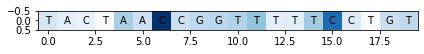

In [38]:
seq, seq_val = calculate_gradient(0)
visualization(seq, seq_val)

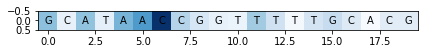

In [39]:
seq, seq_val = calculate_gradient(1)
visualization(seq, seq_val)

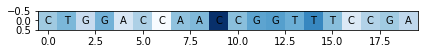

In [40]:
seq, seq_val = calculate_gradient(2)
visualization(seq, seq_val)

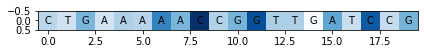

In [41]:
seq, seq_val = calculate_gradient(3)
visualization(seq, seq_val)

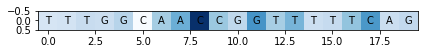

In [43]:
seq, seq_val = calculate_gradient(4)
visualization(seq, seq_val)

### Evaluation

Accuracy

In [42]:
score = model.evaluate(x_t, y_t)
print("accuracy = " + str(round(score[2],4)))

162568/162568 [==============================] - 19s 119us/step
accuracy = 0.6588


loss-epoch curve

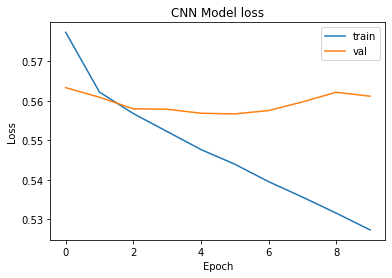

In [44]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('CNN Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['train', 'val'], loc='upper right')
plt.show()

precision-recall curve

In [45]:
probs = model.predict(x_t)[:,1]

In [46]:
precision, recall, thresholds = precision_recall_curve(y_test, probs)

In [47]:
from sklearn.metrics import auc
pr_auc = auc(recall, precision)

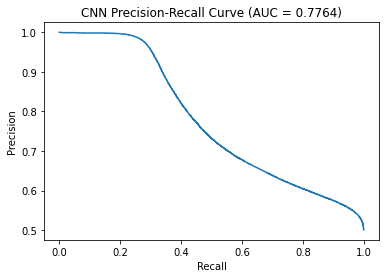

In [48]:
plt.plot(recall, precision)

plt.title('CNN Precision-Recall Curve (AUC = ' + str(round(pr_auc,4)) + ')')

plt.xlabel('Recall')
plt.ylabel('Precision')

plt.show()

ROC curve & AUC

In [49]:
auc = roc_auc_score(y_test, probs)
fpr, tpr, _ = roc_curve(y_test, probs)

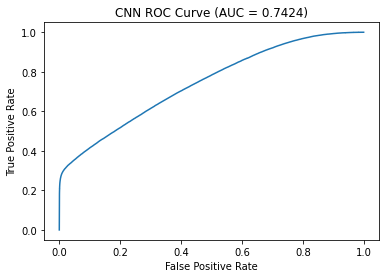

In [50]:
plt.plot(fpr, tpr)
plt.title('CNN ROC Curve (AUC = ' + str(round(auc,4)) + ')')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.show()

save the result

In [51]:
result_dict = {'accuracy': score[2], 'loss': history.history['loss'], 'val_loss': history.history['val_loss'],
               'precision': precision, 'recall': recall, 'tpr': tpr, 'fpr': fpr, 'auc': auc, 'pr_auc': pr_auc}
result_df = pd.DataFrame({ key:pd.Series(value) for key, value in result_dict.items() })
result_df.head()

,accuracy,loss,val_loss,precision,recall,tpr,fpr,auc,pr_auc
0,0.658774,0.577383,0.563359,0.500499,1.000000,0.000000,0.000000,0.742378,0.776435
1,NaN,0.562223,0.560925,0.500496,0.999988,0.011515,0.000012,NaN,NaN
2,NaN,0.556788,0.557994,0.500499,0.999988,0.012697,0.000012,NaN,NaN
3,NaN,0.552237,0.557883,0.500502,0.999988,0.017316,0.000012,NaN,NaN
4,NaN,0.547681,0.556873,0.500505,0.999988,0.018523,0.000025,NaN,NaN


In [52]:
result_df.to_csv ('CNN_result.csv', index = False, header=True)